# Advanced Certification Programme in Agentic and Generative AI
## A Programme by IISc and TalentSprint
## Additional Notebook: **Hotel Management Agentic Application**

## Learning Objectives

At the end of the experiment, you will be able to

* Understand the architecture and workflow of a multi-agent hotel management application
* Build AI agents for room booking and food ordering with tool integration
* Develop backend APIs using FastAPI for agent communication and business operations
* Create an interactive frontend interface using Streamlit
* Integrate AI agents with database tables for real-time hotel management tasks
* Learn end-to-end integration of LLMs, agents, APIs, databases, and frontend UI in a production-style application


## Introduction

The architecture below demonstrates a multi-agent Hotel Management system consisting of a **Supervisor Agent** that coordinates user requests between two specialized agents:
- the Room Booking Agent and
- the Food Ordering Agent.

The **Room Booking Agent** handles hotel reservation workflows using tools such as
- `check_availability_tool` and
- `book_room_tool`,

while the **Food Ordering Agent** manages restaurant-related operations through tools like
- `get_menu`,
- `order_food`, and
- `get_food_bill`.

The agents interact with backend database tables including rooms, reservations, menu, and orders to perform real-time business operations.

The overall system is exposed through **backend** APIs built using `FastAPI` and connected to a **frontend** interface developed with `Streamlit`, providing an end-to-end AI-powered hotel management application.



<img src='https://drive.google.com/uc?id=1w6E_cjtHQ_IYyBO2TjyPmWM0nx5Ll6rP'>

---
---

**Project Folder Structure**

The below figure shows the folder structure of the multi-agent Hotel Management application, organized into separate backend and frontend components.

- The `app/` directory contains the backend implementation developed using FastAPI.

    - Inside the `agents/` folder,

        - the `supervisor_agent.py` file manages the coordination between different agents,
        - while `tools.py` contains the tool functions used by the agents for hotel operations.

    - The `db/` folder includes
        - the database configuration file `database.py` and
        - the SQLite database `hotel_6.db` used for storing hotel-related data such as rooms, reservations, menu items, and orders.

    - The `routers/` folder contains the API endpoint definitions in `supervisor.py`, which expose the agent functionalities through REST APIs.

    - The `main.py` file acts as the primary FastAPI application entry point for running the backend server.

- Additionally, the `streamlit_app.py` file represents the frontend application developed using Streamlit, providing a user-friendly interface to interact with the AI-powered hotel management system.



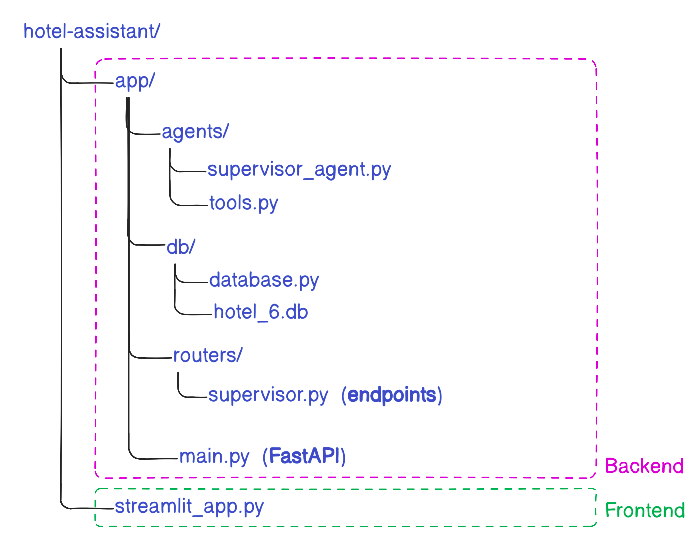

---
---

### Install required dependencies

In [1]:
%%capture
!pip -q install openai==2.3.0
!pip -q install langchain-core==0.3.79
!pip -q install langchain-community==0.3.31
!pip -q install sentence-transformers==5.1.1
!pip -q install langchain-huggingface==0.3.1
!pip -q install langchain-experimental==0.3.4
!pip -q install langchainhub==0.1.21
!pip -q install langchain-openai==0.3.35

# Install LangGraph
!pip -q install langgraph==0.6.8
!pip -q install langgraph-supervisor==0.0.29

### Import required packages

In [2]:
import os
import re
import json
from google.colab import userdata

import openai
from langchain.prompts import PromptTemplate
from langchain_openai import ChatOpenAI

from langchain import hub
from langchain.agents import load_tools

### **Provide your API key**

In [3]:
# Save the key in Colab's Secrets then load from there
import os
from google.colab import userdata

# os.environ['GROQ_API_KEY'] = userdata.get("GROQ_API_KEY")            # <----- If using the Groq API

os.environ['OPENAI_API_KEY'] = userdata.get("OPENAI_API_KEY")        # <----- If using the OpenAI API

### **Load your Language Model**

In [19]:
from langchain_openai import ChatOpenAI

# llm = ChatOpenAI(                                                 # <----- If using the Groq API
#     model="openai/gpt-oss-120b",   # Groq-supported model
#     temperature=0,
#     api_key=os.getenv("GROQ_API_KEY"),
#     base_url="https://api.groq.com/openai/v1"
# )

llm = ChatOpenAI(model_name="gpt-4o", temperature=0)           # <----- If using the OpenAI API


In [20]:
response = llm.invoke("What is 2 plus 3")
print(response.content)

2 plus 3 equals 5.


### **Create Database**

**Database Tables**

* ***rooms*** *(room_number, status)*

* ***reservations*** *(reservation_id, guest_name, room_number)*

* ***menu*** *(item_name, cuisine, price, availability)*

* ***orders*** *(order_id, item_name, quantity, room_number)*


In [6]:
import sqlite3
# --- SQLite DB ---
DB_FILE = "hotel_DB.db"


def init_db():
    conn = sqlite3.connect(DB_FILE, check_same_thread=False)
    cur = conn.cursor()

    cur.execute("""
    DROP TABLE IF EXISTS rooms """)

    cur.execute("""
    DROP TABLE IF EXISTS reservations """)

    cur.execute("""
    DROP TABLE IF EXISTS menu """)

    cur.execute("""
    DROP TABLE IF EXISTS orders  """)


    # rooms table
    cur.execute("""
    CREATE TABLE rooms (
        room_number INTEGER UNIQUE PRIMARY KEY,
        status TEXT
    )
    """)

    # reservations table
    cur.execute("""
    CREATE TABLE reservations (
        reservation_id INTEGER PRIMARY KEY,
        guest_name TEXT,
        room_number INTEGER,
        FOREIGN KEY(room_number) REFERENCES rooms(room_number)
    )
    """)

    # menu table
    cur.execute("""
    CREATE TABLE menu  (
        item_name TEXT UNIQUE PRIMARY KEY,
        cuisine TEXT,
        price REAL NOT NULL,
        availability TEXT
    )
    """)

    # orders table
    cur.execute("""
    CREATE TABLE orders (
        order_id INTEGER PRIMARY KEY AUTOINCREMENT,
        item_name TEXT NOT NULL,
        quantity INTEGER NOT NULL,
        room_number INTEGER NOT NULL,

        FOREIGN KEY(room_number) REFERENCES reservations(room_number)
        FOREIGN KEY (item_name) REFERENCES menu(item_name)
    )
    """)


    # Insert sample rooms
    cur.executemany("""
    INSERT OR IGNORE INTO rooms (room_number, status)
    VALUES (?, ?)
    """, [
        (101,"available"),
        (102,"occupied"),
        (103, "available"),
        (104, "available"),
        (105, "available"),
        (106, "occupied"),
        (201, "available"),
        (202, "occupied"),
        (203, "available"),
    ])

    # Insert sample menu
    cur.executemany("""
    INSERT OR IGNORE INTO menu (item_name, cuisine, price, availability)
    VALUES (?, ?, ?, ?)
    """, [
        ("Paneer Butter Masala + 2 Roti","North Indian",450,"available"),
        ("2 Idli + 2 Wada","South Indian",200,"available"),
        ("North Indian Thali","North Indian",510,"available"),
        ("South Indian Thali","South Indian",510,"available"),
        ("Pav Bhaji","North Indian",175,"available"),
        ("Manchurian","Chinese",310,"not available"),
        ("Pasta","Italian",360,"available"),
        ("Noodles","Chinese",310,"available"),
        ("Pizza","Italian",410,"not available"),

    ])


    conn.commit()
    conn.close()


init_db()
print("Hotel DB initialized.")


Hotel DB initialized.


In [7]:
# Function that executes a SQL query on the SQLite database and returns the result set

def sql_query(query):
    conn = sqlite3.connect(DB_FILE)
    cursor = conn.cursor()
    cursor.execute(query)
    return cursor.fetchall()

In [8]:
sql_query("SELECT * FROM rooms")

[(101, 'available'),
 (102, 'occupied'),
 (103, 'available'),
 (104, 'available'),
 (105, 'available'),
 (106, 'occupied'),
 (201, 'available'),
 (202, 'occupied'),
 (203, 'available')]

In [9]:
sql_query("SELECT * FROM menu")

[('Paneer Butter Masala + 2 Roti', 'North Indian', 450.0, 'available'),
 ('2 Idli + 2 Wada', 'South Indian', 200.0, 'available'),
 ('North Indian Thali', 'North Indian', 510.0, 'available'),
 ('South Indian Thali', 'South Indian', 510.0, 'available'),
 ('Pav Bhaji', 'North Indian', 175.0, 'available'),
 ('Manchurian', 'Chinese', 310.0, 'not available'),
 ('Pasta', 'Italian', 360.0, 'available'),
 ('Noodles', 'Chinese', 310.0, 'available'),
 ('Pizza', 'Italian', 410.0, 'not available')]

In [10]:
sql_query("SELECT * FROM reservations")

[]

In [11]:
sql_query("SELECT * FROM orders")

[]

---
## **Designing Tools and Agents**
---

In [12]:
## Common dependencies

from langchain_core.tools import tool
from langgraph.graph import StateGraph, MessagesState, START, END
from langgraph.prebuilt import ToolNode, create_react_agent, tools_condition
from langchain_openai import ChatOpenAI
from langgraph.graph.message import add_messages

from typing import TypedDict, List, Optional, Annotated
from langchain_core.messages import BaseMessage
from langchain_core.messages import HumanMessage, AIMessage
from langgraph.checkpoint.memory import MemorySaver

class State(TypedDict):
    messages: Annotated[list, add_messages]


/usr/local/lib/python3.12/dist-packages/langgraph/cache/base/__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


### **Room Booking Agent**

In [32]:
############# room_booking ###################

@tool
def check_availability_tool() -> str:
    """Check which rooms are available in the hotel."""
    print(f" CALLING Tool: check_availability_tool()")

    conn = sqlite3.connect(DB_FILE)
    cursor = conn.cursor()
    cursor.execute("SELECT * FROM rooms WHERE status='available'")
    rows = cursor.fetchall()
    conn.close()
    if not rows:
        return "No rooms available."
    print(f"Tool Output: {rows}")
    return f"Available rooms: {', '.join(str(r[0]) for r in rows)}"


@tool
def book_room_tool(guest_name: str, room_number: int) -> str:
    """Book the SPECIFIC room requested by the guest.
    The `room_number` argument MUST always be passed exactly as the user asked.
    First check if the room_number is available,
    If that room is not available, return an error message instead of booking another room."""

    print(f" CALLING Tool: book_room_tool()")
    print(f" PARAMS: guest_name='{guest_name}', room_number={room_number}")


    conn = sqlite3.connect(DB_FILE)
    cursor = conn.cursor()

    if room_number:
        # Book specific room
        cursor.execute("SELECT * FROM rooms WHERE room_number=? AND status='available'", (room_number,))
        room = cursor.fetchone()
        if not room:
            conn.close()
            return f"Room {room_number} is not available."
        target_room = room_number
    else:
        return f"Room {room_number} is not a valid room number."

    cursor.execute("UPDATE rooms SET status='occupied' WHERE room_number=?", (target_room,))
    cursor.execute("INSERT INTO reservations (guest_name, room_number) VALUES (?, ?)",
                   (guest_name, target_room))
    conn.commit()
    conn.close()
    print(f"Tool Output: Room {target_room} booked for {guest_name}.")
    return f"Room {target_room} booked for {guest_name}."


# --- 1. Define tools ---
room_booking_tools = [check_availability_tool, book_room_tool]

room_booking_system_message = """
You are a hotel booking assistant.
Required information to book a room:
- Guest name
- Room number

Your rules:
1. If any required information is missing, DO NOT call tools yet.
   Instead, ask the user for the missing information.
2. Only call `book_room_tool` once you have both guest name AND room number.
3. Use `check_availability_tool` if the user asks which rooms are free.
"""

# --- 2. Build LLM agent with tools ---
room_booking_agent = create_react_agent(llm, room_booking_tools, prompt=room_booking_system_message)


# --- 4. Build graph ---
room_booking_graph_builder = StateGraph(State)

# Nodes
room_booking_graph_builder.add_node("agent", room_booking_agent)

room_booking_tool_node = ToolNode(tools=room_booking_tools)

room_booking_graph_builder.add_node("tools", room_booking_tool_node)

# Edges
room_booking_graph_builder.add_conditional_edges("agent", tools_condition)  # if tool needed, go to tools
room_booking_graph_builder.add_edge("tools", "agent")
room_booking_graph_builder.set_entry_point("agent")

room_booking_memory = MemorySaver()

# Compile
room_booking_graph = room_booking_graph_builder.compile(checkpointer=room_booking_memory)


In [22]:
#@title Load the function `display_workflow_graph()`

## Render a LangGraph-style Mermaid string in Jupyter/Colab

from IPython.display import HTML, display
import json, re

def display_workflow_graph(workflow_app):
    mermaid_str = workflow_app.get_graph().draw_mermaid()
    s = str(mermaid_str).strip()
    cfg_json = "{}"

    # Extract optional YAML front-matter like:
    # ---
    # config:
    #   flowchart:
    #     curve: linear
    # ---
    m = re.match(r"^---\s*(.*?)\s*---\s*(graph\s+\w+;.*)$", s, re.S)
    if m:
        yaml_block, diagram = m.group(1), m.group(2)
        try:
            import yaml  # pip install pyyaml (only once if missing)
            data = yaml.safe_load(yaml_block) or {}
            cfg_json = json.dumps(data.get("config", {}))
        except Exception:
            diagram = s.split('---')[-1].strip()
    else:
        diagram = s

    # Convert YAML config to Mermaid init directive + embed and render
    directive = f"%%{{init: {cfg_json}}}%%\n"
    html = f"""
    <div class="mermaid">
    {directive}
    {diagram}
    </div>
    <script>
    (function() {{
      function boot() {{
        if (window.mermaid) {{
          mermaid.initialize({{ startOnLoad: true, securityLevel: 'loose' }});
          mermaid.contentLoaded();
        }} else {{
          var s = document.createElement('script');
          s.src = "https://cdn.jsdelivr.net/npm/mermaid/dist/mermaid.min.js";
          s.onload = function() {{
            mermaid.initialize({{ startOnLoad: true, securityLevel: 'loose' }});
            mermaid.contentLoaded();
          }};
          document.head.appendChild(s);
        }}
      }}
      boot();
    }})();
    </script>
    """
    display(HTML(html))


In [33]:
display_workflow_graph(room_booking_graph)

In [34]:
# Test the agent

input = {"messages": [HumanMessage(content="Which rooms are available")]}

response = room_booking_graph.invoke(input, {"configurable": {"thread_id": "1"}})

print("--------------------------------")
print(response["messages"][-1].content)

 CALLING Tool: check_availability_tool()
Tool Output: [(101, 'available'), (103, 'available'), (104, 'available'), (105, 'available'), (201, 'available'), (203, 'available')]
--------------------------------
The available rooms are: 101, 103, 104, 105, 201, and 203.


### **Food Ordering Agent**

In [26]:
############# food_ordering ###################

@tool
def get_menu() -> str:
    """Get the current menu with availability."""
    print(f" CALLING Tool: get_menu() Tool")

    conn = sqlite3.connect(DB_FILE)
    c = conn.cursor()
    c.execute("SELECT item_name, cuisine, price FROM menu WHERE availability = 'available'")
    rows = c.fetchall()
    conn.close()

    if not rows:
        return "Menu is currently empty."

    menu_str = "\n".join(
        [f"{name} ({cuisine}) - ₹{price}]"
         for name, cuisine, price in rows]
    )
    print(f"Tool Output: Today's Menu:\n  {menu_str}")
    return "Today's Menu:\n" + menu_str


@tool
def order_food(item_name: str, quantity: int, room_number: int) -> str:
    """Place a food order for a guest (linked to room)."""

    print(f" CALLING Tool: order_food()")
    print(f" PARAMS: item_name='{item_name}', quantity='{quantity}', room_number={room_number}")


    conn = sqlite3.connect(DB_FILE)
    c = conn.cursor()

    # Validate room
    c.execute("SELECT status FROM rooms WHERE room_number = ?", (room_number,))
    room = c.fetchone()
    if not room:
        conn.close()
        return f"Room {room_number} does not exist."
    if room[0] != "occupied":
        conn.close()
        return f"Room {room_number} is not occupied."

    # Validate dish
    c.execute("SELECT availability FROM menu WHERE item_name = ?", (item_name,))
    row = c.fetchone()
    if not row:
        conn.close()
        return f"Item Name '{item_name}' not found in menu."
    if row[0] == "not available":
        conn.close()
        return f"Sorry, '{item_name}' is not available right now."

    # Insert order
    c.execute("INSERT INTO orders (item_name, quantity, room_number) VALUES (?, ?, ?)",
              (item_name, quantity, room_number))
    order_id = c.lastrowid
    conn.commit()
    conn.close()

    print(f"Tool Output => Order placed: {quantity} x {item_name} for Room {room_number}. Order ID: {order_id}.")

    return f"Order placed: {quantity} x {item_name} for Room {room_number}. Order ID: {order_id}."



@tool
def get_food_bill(room_number: int) -> str:
    """Calculate the total food bill for a room."""

    print(f" CALLING Tool: get_food_bill()")
    print(f" PARAMS: room_number={room_number}")


    conn = sqlite3.connect(DB_FILE)
    c = conn.cursor()

    c.execute("""
        SELECT o.item_name, o.quantity, m.price
        FROM orders o
        JOIN menu m ON o.item_name = m.item_name
        WHERE o.room_number = ?
    """, (room_number,))
    rows = c.fetchall()
    conn.close()

    if not rows:
        return f"No active food orders found for Room {room_number}."

    total = 0
    bill_lines = []
    for dish, quantity, price in rows:
        subtotal = quantity * price
        total += subtotal
        bill_lines.append(f"{dish} x {quantity} = ₹{subtotal}")

    bill = "\n".join(bill_lines) + f"\n\n Total Bill: ₹{total}"

    print(f"Tool Output {bill}")
    return bill



# --- 1. Define tools ---
order_food_tools = [get_menu, order_food, get_food_bill]


order_food_system_message = """
You are a hotel food ordering assistant.

Available tools:
- get_menu → Show available dishes.
- order_food → Place a food order for a guest (requires dish, quantity, and room number).
- get_food_bill → Show the food bill for a room (requires room number).

Your rules:
1. Always confirm missing required details with the guest before calling a tool.
   - For `order_food`, ask for dish name, quantity, and room number if any is missing.
   - For `get_food_bill`, ask for the room number if missing.
2. Only call a tool when all required parameters are available.
3. When showing the menu, only list available items (tool handles this).
4. After placing an order, confirm the action back to the guest.
5. Be polite and conversational while guiding the guest.
"""


# --- 2. Build LLM agent with tools ---
order_food_agent = create_react_agent(llm, order_food_tools, prompt=order_food_system_message)


# --- 4. Build graph ---
order_food_graph_builder = StateGraph(State)

# Nodes
order_food_graph_builder.add_node("agent", order_food_agent)

order_food_tool_node = ToolNode(tools=order_food_tools)

order_food_graph_builder.add_node("tools", order_food_tool_node)

# Edges
order_food_graph_builder.add_conditional_edges("agent", tools_condition)  # if tool needed, go to tools
order_food_graph_builder.add_edge("tools", "agent")
order_food_graph_builder.set_entry_point("agent")

order_food_memory = MemorySaver()

# Compile
order_food_graph = order_food_graph_builder.compile(checkpointer=order_food_memory)


In [27]:
display_workflow_graph(order_food_graph)

In [35]:
# Test the agent

input = {"messages": [HumanMessage(content="Show me the menu")]}

response = order_food_graph.invoke(input, {"configurable": {"thread_id": "1"}})

print("--------------------------------")
print(response["messages"][-1].content)

 CALLING Tool: get_menu() Tool
Tool Output: Today's Menu:
  Paneer Butter Masala + 2 Roti (North Indian) - ₹450.0]
2 Idli + 2 Wada (South Indian) - ₹200.0]
North Indian Thali (North Indian) - ₹510.0]
South Indian Thali (South Indian) - ₹510.0]
Pav Bhaji (North Indian) - ₹175.0]
Pasta (Italian) - ₹360.0]
Noodles (Chinese) - ₹310.0]
--------------------------------
Here's today's menu for you:

1. **Paneer Butter Masala + 2 Roti** (North Indian) - ₹450.0
2. **2 Idli + 2 Wada** (South Indian) - ₹200.0
3. **North Indian Thali** (North Indian) - ₹510.0
4. **South Indian Thali** (South Indian) - ₹510.0
5. **Pav Bhaji** (North Indian) - ₹175.0
6. **Pasta** (Italian) - ₹360.0
7. **Noodles** (Chinese) - ₹310.0

Let me know if you'd like to order anything!


### **Supervisor Agent**

In [36]:

@tool
def booking_agent_tool(messages: list) -> str:
    """Interact with the booking agent"""
    print(" **** CALLING Agent: booking_agent *******")

    response = room_booking_graph.invoke({"messages": messages})
    return response["messages"][-1].content

@tool
def food_agent_tool(messages: list) -> str:
    """Interact with the food ordering agent"""
    print(" **** CALLING Agent: food_agent *******")

    response = order_food_graph.invoke({"messages": messages})
    return response["messages"][-1].content



supervisor_tools = [booking_agent_tool, food_agent_tool]

supervisor_system_message = """
You are the hotel concierge agent.
- For room related queries, call `booking_agent_tool`.
- For food related queries, call `food_agent_tool`.
- Keep the conversation natural.
"""

supervisor_agent = create_react_agent(llm, supervisor_tools, prompt=supervisor_system_message)


supervisor_graph_builder = StateGraph(State)

supervisor_graph_builder.add_node("supervisor_agent", supervisor_agent)
supervisor_tool_node = ToolNode(tools=supervisor_tools)
supervisor_graph_builder.add_node("tools", supervisor_tool_node)

supervisor_graph_builder.add_conditional_edges("supervisor_agent", tools_condition)
supervisor_graph_builder.add_edge("tools", "supervisor_agent")
supervisor_graph_builder.set_entry_point("supervisor_agent")

# memory for supervisor agent
supervisor_memory = MemorySaver()

supervisor_graph = supervisor_graph_builder.compile(checkpointer= supervisor_memory)


In [37]:
display_workflow_graph(supervisor_graph)

#### Invoke Function

In [38]:
from langchain_core.messages import HumanMessage, AIMessage

conf = {"configurable": {"thread_id": "1"}}


def supervisor_graph_call(human_message):
    response = supervisor_graph.invoke(
        {"messages": [HumanMessage(content=human_message)]},conf)
    print("--------------------------------")
    print(response["messages"][-1].content)


## **Interact with the Agent**

#### Room Booking

In [39]:
supervisor_graph_call("Which rooms are available")


 **** CALLING Agent: booking_agent *******
 CALLING Tool: check_availability_tool()
Tool Output: [(101, 'available'), (103, 'available'), (104, 'available'), (105, 'available'), (201, 'available'), (203, 'available')]
--------------------------------
The available rooms are 101, 103, 104, 105, 201, and 203. Let me know if you need more information or assistance with booking!


In [40]:
supervisor_graph_call("Book room 105")


 **** CALLING Agent: booking_agent *******
--------------------------------
Could you please provide the guest's name so I can proceed with booking room 105 for you?


In [41]:
supervisor_graph_call("Bharath")


 **** CALLING Agent: booking_agent *******
 CALLING Tool: book_room_tool()
 PARAMS: guest_name='Bharath', room_number=105
Tool Output: Room 105 booked for Bharath.
--------------------------------
Room 105 has been successfully booked for Bharath. If you need anything else, feel free to ask!


In [42]:
sql_query("SELECT * FROM reservations")

[(1, 'Bharath', 105)]

In [43]:

supervisor_graph_call("Book room 103 for Srikanth")


 **** CALLING Agent: booking_agent *******
 CALLING Tool: book_room_tool()
 PARAMS: guest_name='Srikanth', room_number=103
Tool Output: Room 103 booked for Srikanth.
--------------------------------
Room 103 has been successfully booked for Srikanth. If there's anything else you need, just let me know!


In [44]:

supervisor_graph_call("Book room 103 for Ramesh")


--------------------------------
Room 103 is already booked for Srikanth. Would you like to choose another available room for Ramesh? The available rooms are 101, 104, 105, 201, and 203.


In [45]:

supervisor_graph_call("Which rooms are available?")


 **** CALLING Agent: booking_agent *******
 CALLING Tool: check_availability_tool()
Tool Output: [(101, 'available'), (104, 'available'), (201, 'available'), (203, 'available')]
--------------------------------
The available rooms are 101, 104, 201, and 203. Let me know if you'd like to book one of these for Ramesh!


In [46]:

supervisor_graph_call("Book room 203 for Ramesh")


 **** CALLING Agent: booking_agent *******
 CALLING Tool: book_room_tool()
 PARAMS: guest_name='Ramesh', room_number=203
Tool Output: Room 203 booked for Ramesh.
--------------------------------
Room 203 has been successfully booked for Ramesh. If there's anything else you need, feel free to ask!


In [47]:
## Confirm in DB
sql_query("SELECT * FROM reservations")

[(1, 'Bharath', 105), (2, 'Srikanth', 103), (3, 'Ramesh', 203)]

#### Food Ordering

In [48]:
supervisor_graph_call("what south indian food is available")

 **** CALLING Agent: food_agent *******
 CALLING Tool: get_menu() Tool
Tool Output: Today's Menu:
  Paneer Butter Masala + 2 Roti (North Indian) - ₹450.0]
2 Idli + 2 Wada (South Indian) - ₹200.0]
North Indian Thali (North Indian) - ₹510.0]
South Indian Thali (South Indian) - ₹510.0]
Pav Bhaji (North Indian) - ₹175.0]
Pasta (Italian) - ₹360.0]
Noodles (Chinese) - ₹310.0]
--------------------------------
We have the following South Indian dishes available today:

1. 2 Idli + 2 Wada for ₹200.0
2. South Indian Thali for ₹510.0

Let me know if you'd like to place an order!


In [49]:
supervisor_graph_call("I want to order 2 pav bhaji")

 **** CALLING Agent: food_agent *******
--------------------------------
Could you please provide your room number so I can place the order for 2 Pav Bhaji?


In [50]:
supervisor_graph_call("103")

 **** CALLING Agent: food_agent *******
 CALLING Tool: order_food()
 PARAMS: item_name='Pav Bhaji', quantity='2', room_number=103
Tool Output => Order placed: 2 x Pav Bhaji for Room 103. Order ID: 1.
--------------------------------
Your order for 2 Pav Bhaji has been successfully placed for Room 103. Enjoy your meal! If there's anything else you need, just let me know.


In [51]:
## check in db
sql_query("SELECT * FROM orders")

[(1, 'Pav Bhaji', 2, 103)]

In [52]:
supervisor_graph_call("Order 3 South Indian Thali to room 105")

 **** CALLING Agent: food_agent *******
 CALLING Tool: get_menu() Tool
Tool Output: Today's Menu:
  Paneer Butter Masala + 2 Roti (North Indian) - ₹450.0]
2 Idli + 2 Wada (South Indian) - ₹200.0]
North Indian Thali (North Indian) - ₹510.0]
South Indian Thali (South Indian) - ₹510.0]
Pav Bhaji (North Indian) - ₹175.0]
Pasta (Italian) - ₹360.0]
Noodles (Chinese) - ₹310.0]
 CALLING Tool: order_food()
 PARAMS: item_name='South Indian Thali', quantity='3', room_number=105
Tool Output => Order placed: 3 x South Indian Thali for Room 105. Order ID: 2.
--------------------------------
Your order for 3 South Indian Thalis has been successfully placed for Room 105. If there's anything else you need, just let me know!


In [64]:
supervisor_graph_call("Order 2 servings of Pasta and 1 Noodles to room 105")

**** CALLING Agent: food_agent *******
 CALLING Tool: get_menu() Tool
Tool Output: Today's Menu:
  Paneer Butter Masala + 2 Roti (North Indian) - ₹450.0]
2 Idli + 2 Wada (South Indian) - ₹200.0]
North Indian Thali (North Indian) - ₹510.0]
South Indian Thali (South Indian) - ₹510.0]
Pav Bhaji (North Indian) - ₹175.0]
Pasta (Italian) - ₹360.0]
Noodles (Chinese) - ₹310.0]
 CALLING Tool: order_food()
 PARAMS: item_name='Pasta', quantity='2', room_number=105
 CALLING Tool: order_food()
 PARAMS: item_name='Noodles', quantity='1', room_number=105
Tool Output => Order placed: 2 x Pasta for Room 105. Order ID: 3.
Tool Output => Order placed: 1 x Noodles for Room 105. Order ID: 4.
--------------------------------
Your order has been successfully placed for Room 105:

- 2 servings of Pasta
- 1 serving of Noodles

Enjoy your meal! 🍝🍜



In [61]:
supervisor_graph_call("I want food bill")

--------------------------------
Could you please provide your room number so I can retrieve your food bill for you?


In [62]:
supervisor_graph_call("105")

 **** CALLING Agent: food_agent *******
 CALLING Tool: get_food_bill()
 PARAMS: room_number=105
Tool Output South Indian Thali x 3 = ₹1530.0
Pasta x 2 = ₹720.0
Noodles x 1 = ₹310.0

 Total Bill: ₹2560.0
--------------------------------
The food bill for room 105 includes:

- 3 South Indian Thalis: ₹1530.0
- 2 servings of Pasta: ₹720.0
- 1 serving of Noodles: ₹310.0

The total bill amounts to ₹2560.0. If there's anything else you need, feel free to ask!


In [63]:
sql_query("SELECT * FROM orders")

[(1, 'Pav Bhaji', 2, 103),
 (2, 'South Indian Thali', 3, 105),
 (3, 'Pasta', 2, 105),
 (4, 'Noodles', 1, 105)]

---
$$END$$

---